# PPE Detection Training Notebook — YOLO26

**Goal:** Train and evaluate a YOLO26 object detection model on the PPE dataset.

This notebook is structured for final submission:
- Dataset checking and class statistics
- YOLO26 training
- Validation and testing
- Training curves and confusion matrix
- Prediction visualization on test images
- Exported model paths: `best.pt` and `last.pt`

> Before submitting: run all cells, save the notebook with visible outputs, and make sure the metrics in the LaTeX report match this notebook.


In [ ]:

!python -m pip install -U ultralytics roboflow pandas matplotlib pillow pyyaml opencv-python tqdm

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -------------------------------- ------- 1.0/1.3 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 9.2 MB/s  0:00:00

  Attempting uninstall: tqdm

    Found existing installation: tqdm 4.67.3

    Uninstalling tqdm-4.67.3:

      Successfully uninstalled tqdm-4.67.3

   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
  Attempting uninstall: ultralytics
   ---------------------------------------- 0/2 [tqdm]
    Found existing installation: ultralytics 8.4.43
   ---------------------------------------- 0/2 [tqdm]
   -------------------- ------------------- 1/2 [ultralytics]
    Uninstalling ultralytics-8.4.43:
   -------------------- ------------------- 1/2 [ultralytics]
      Successfully uninstalled ultralytics-8.4.43
   -------------------- ------------------- 1/2 [ultraly

In [ ]:

from pathlib import Path
import os
import random
import shutil
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IPyImage

import torch
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PROJECT_ROOT = Path(r"D:/Training + AI/PPE Train")

if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

DATASET_DIR = PROJECT_ROOT / "datasets" / "PPE-3"
DATA_YAML = DATASET_DIR / "data.yaml"

RUN_PROJECT = PROJECT_ROOT / "runs_yolo26"
RUN_NAME = "yolo26n_ppe"

YOLO_MODEL = "yolo26n.pt"   
EPOCHS = 50                
IMGSZ = 640
BATCH = 8                   
WORKERS = 0                 
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_YAML:", DATA_YAML)
print("RUN_PROJECT:", RUN_PROJECT)


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3080
PROJECT_ROOT: D:\Training + AI\PPE Train
DATA_YAML: D:\Training + AI\PPE Train\datasets\PPE-3\data.yaml
RUN_PROJECT: D:\Training + AI\PPE Train\runs_yolo26


## 2. Dataset loading

Use the existing YOLO-format dataset if `data.yaml` already exists.

If the dataset is not available locally, uncomment the Roboflow cell below and fill your API key/workspace/project/version.


In [ ]:
assert DATA_YAML.exists(), f"data.yaml not found: {DATA_YAML}"

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print("data.yaml content:")
print(data_cfg)

names = data_cfg.get("names")
if isinstance(names, dict):
    class_names = [names[i] for i in sorted(names.keys())]
else:
    class_names = list(names)

num_classes = len(class_names)
print("\nNumber of classes:", num_classes)
print("Class names:", class_names)

for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"
    print(f"{split:5s} images:", len(list(img_dir.glob("*.*"))) if img_dir.exists() else "missing",
          "| labels:", len(list(label_dir.glob("*.txt"))) if label_dir.exists() else "missing")


data.yaml content:
{'names': ['Gloves', 'Goggles', 'Helmet', 'No-Gloves', 'No-Goggles', 'No-Helmet', 'Person'], 'nc': 7, 'roboflow': {'license': 'Public Domain', 'project': 'ppe-8k2vo', 'url': 'https://universe.roboflow.com/ppe-ihvqu/ppe-8k2vo/dataset/3', 'version': 3, 'workspace': 'ppe-ihvqu'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Number of classes: 7
Class names: ['Gloves', 'Goggles', 'Helmet', 'No-Gloves', 'No-Goggles', 'No-Helmet', 'Person']
train images: 8160 | labels: 8160
valid images: 905 | labels: 905
test  images: 903 | labels: 903


,split,total_boxes,Gloves,Goggles,Helmet,No-Gloves,No-Goggles,No-Helmet,Person
0,train,35238,5206,3819,8178,2526,1153,2489,11867
1,valid,3819,535,418,900,269,130,264,1303
2,test,3823,543,432,936,244,117,235,1316


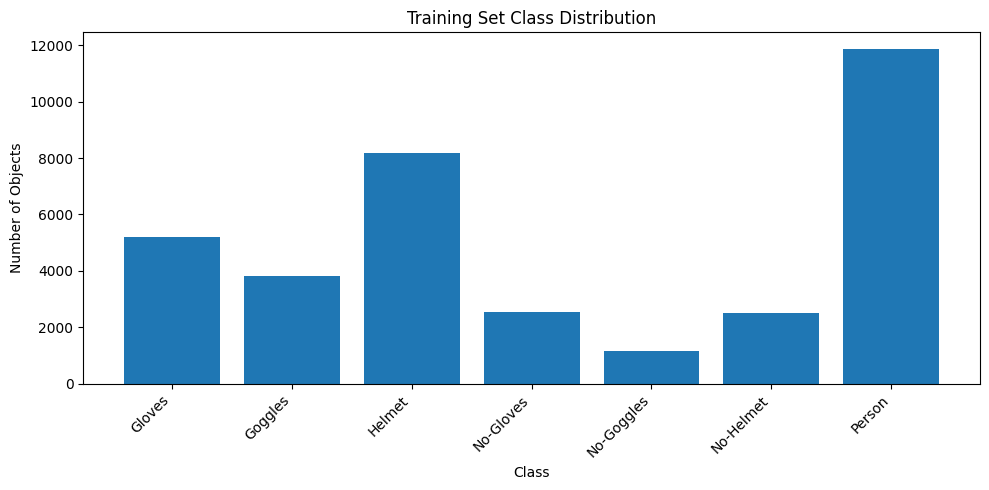

In [ ]:
def count_yolo_labels(label_dir: Path, n_classes: int):
    counts = [0] * n_classes
    total_boxes = 0
    if not label_dir.exists():
        return counts, total_boxes

    for txt in label_dir.glob("*.txt"):
        lines = txt.read_text(encoding="utf-8").strip().splitlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(float(parts[0]))
                if 0 <= cls_id < n_classes:
                    counts[cls_id] += 1
                    total_boxes += 1
    return counts, total_boxes

stats = []
for split in ["train", "valid", "test"]:
    counts, total_boxes = count_yolo_labels(DATASET_DIR / split / "labels", num_classes)
    row = {"split": split, "total_boxes": total_boxes}
    for i, name in enumerate(class_names):
        row[name] = counts[i]
    stats.append(row)

df_stats = pd.DataFrame(stats)
display(df_stats)

train_counts = df_stats[df_stats["split"] == "train"][class_names].iloc[0]
plt.figure(figsize=(10, 5))
plt.bar(class_names, train_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()


## 4. Train YOLO26

The training output will be saved under:

```text
runs_yolo26/yolo26n_ppe/
├── weights/best.pt
├── weights/last.pt
├── results.csv
├── results.png
├── confusion_matrix.png
└── ...
```


In [ ]:

model = YOLO(YOLO_MODEL)

train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project=str(RUN_PROJECT),
    name=RUN_NAME,
    exist_ok=True,
    pretrained=True,
    optimizer="auto",
    amp=True,
    cache=False,
    plots=True,
    val=True,
    patience=15,
)

RUN_DIR = RUN_PROJECT / RUN_NAME
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

print("Training finished.")
print("Run directory:", RUN_DIR)
print("best.pt:", BEST_PT, "| exists:", BEST_PT.exists())
print("last.pt:", LAST_PT, "| exists:", LAST_PT.exists())


Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Training + AI\PPE Train\datasets\PPE-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_ppe, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [ ]:

assert BEST_PT.exists(), f"best.pt not found: {BEST_PT}"

best_model = YOLO(str(BEST_PT))

val_metrics = best_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
)

print("Validation metrics object:")
print(val_metrics)

try:
    print("mAP50-95:", float(val_metrics.box.map))
    print("mAP50:", float(val_metrics.box.map50))
    print("mAP75:", float(val_metrics.box.map75))
    print("Precision:", float(val_metrics.box.mp))
    print("Recall:", float(val_metrics.box.mr))
except Exception as e:
    print("Could not extract all metrics automatically:", e)


Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.40.0 ms, read: 98.122.9 MB/s, size: 52.8 KB)
val: Scanning D:\Training + AI\PPE Train\datasets\PPE-3\valid\labels.cache... 905 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 905/905  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 114/114 6.1it/s 18.7s0.2s
                   all        905       3819      0.639      0.641      0.641      0.494
                Gloves        319        535      0.778      0.716      0.764      0.616
               Goggles        360        418       0.69      0.741      0.746      0.571
                Helmet        421        900      0.789      0.888      0.883      0.716
             No-Gloves        195        269       0.46      0.405      0.385      0.243
            No-

In [ ]:

test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
)

print("Test metrics object:")
print(test_metrics)

try:
    test_summary = {
        "model": YOLO_MODEL,
        "mAP50-95": float(test_metrics.box.map),
        "mAP50": float(test_metrics.box.map50),
        "mAP75": float(test_metrics.box.map75),
        "Precision": float(test_metrics.box.mp),
        "Recall": float(test_metrics.box.mr),
    }
    df_test_summary = pd.DataFrame([test_summary])
    display(df_test_summary)
    df_test_summary.to_csv(RUN_DIR / "test_summary_yolo26.csv", index=False)
    print("Saved:", RUN_DIR / "test_summary_yolo26.csv")
except Exception as e:
    print("Could not create test summary:", e)


Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
val: Fast image access  (ping: 0.60.1 ms, read: 9.32.3 MB/s, size: 63.6 KB)
val: Scanning D:\Training + AI\PPE Train\datasets\PPE-3\test\labels... 903 images, 24 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 903/903 225.8it/s 4.0s0.1s
val: New cache created: D:\Training + AI\PPE Train\datasets\PPE-3\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 5.8it/s 19.6s0.2s
                   all        903       3823      0.611       0.65      0.639      0.492
                Gloves        309        543      0.746      0.692      0.758      0.593
               Goggles        354        432      0.721      0.787      0.796      0.598
                Helmet        436        936       0.77      0.889      0.865      0.692
             No-Gloves        178        244       0.42      0.422      0.341      0.236
          

,model,mAP50-95,mAP50,mAP75,Precision,Recall
0,yolo26n.pt,0.492469,0.639103,0.535202,0.61088,0.64955


Saved: D:\Training + AI\PPE Train\runs_yolo26\yolo26n_ppe\test_summary_yolo26.csv


Displaying: results.png


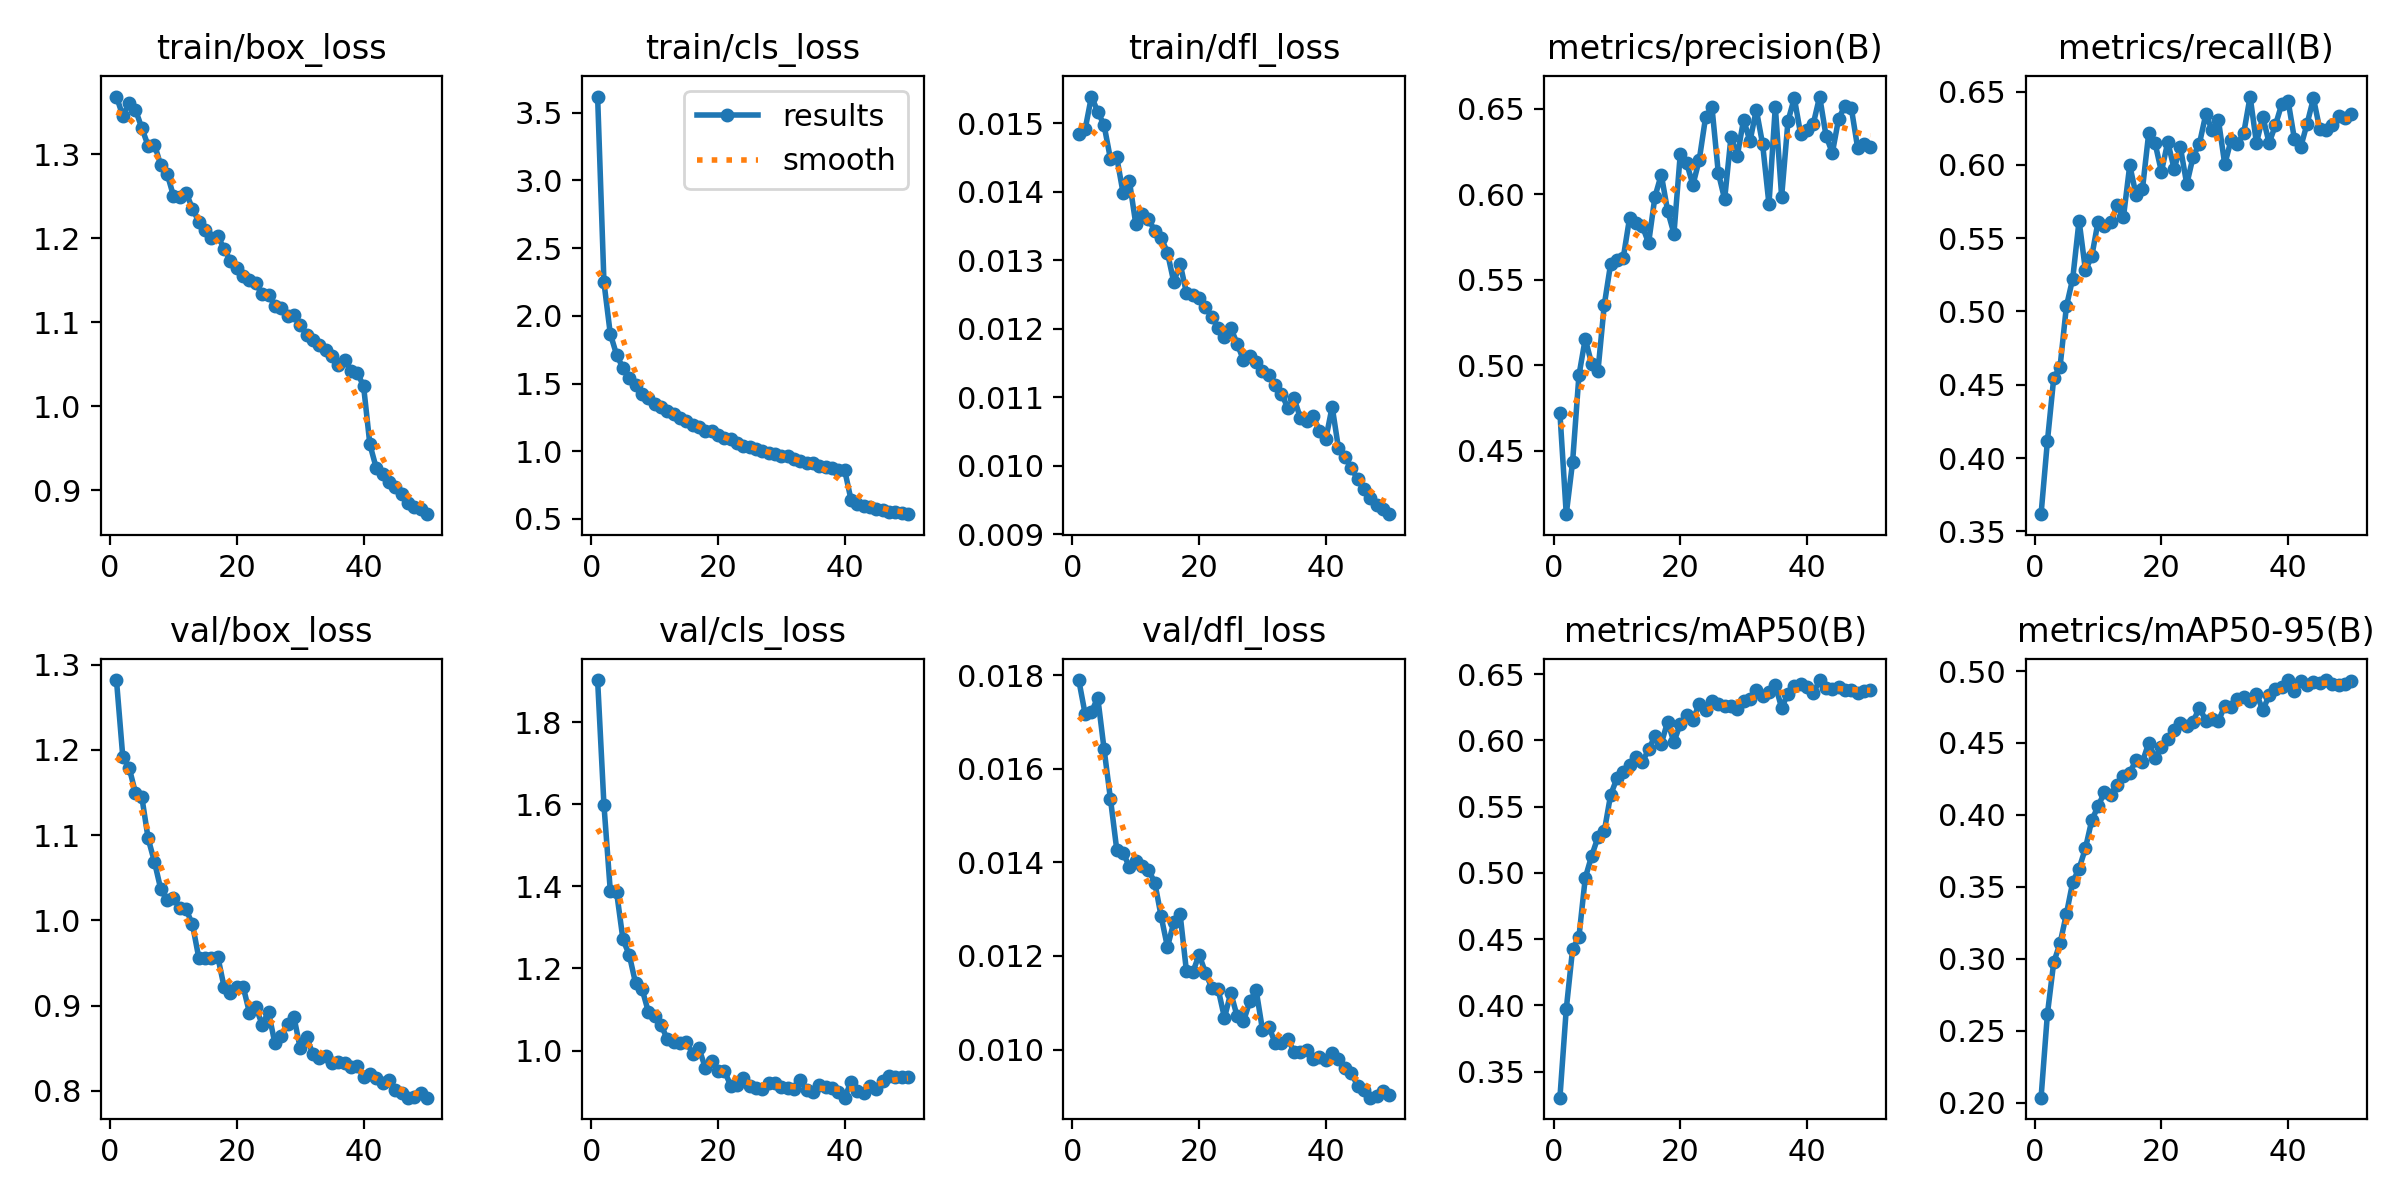

Displaying: confusion_matrix.png


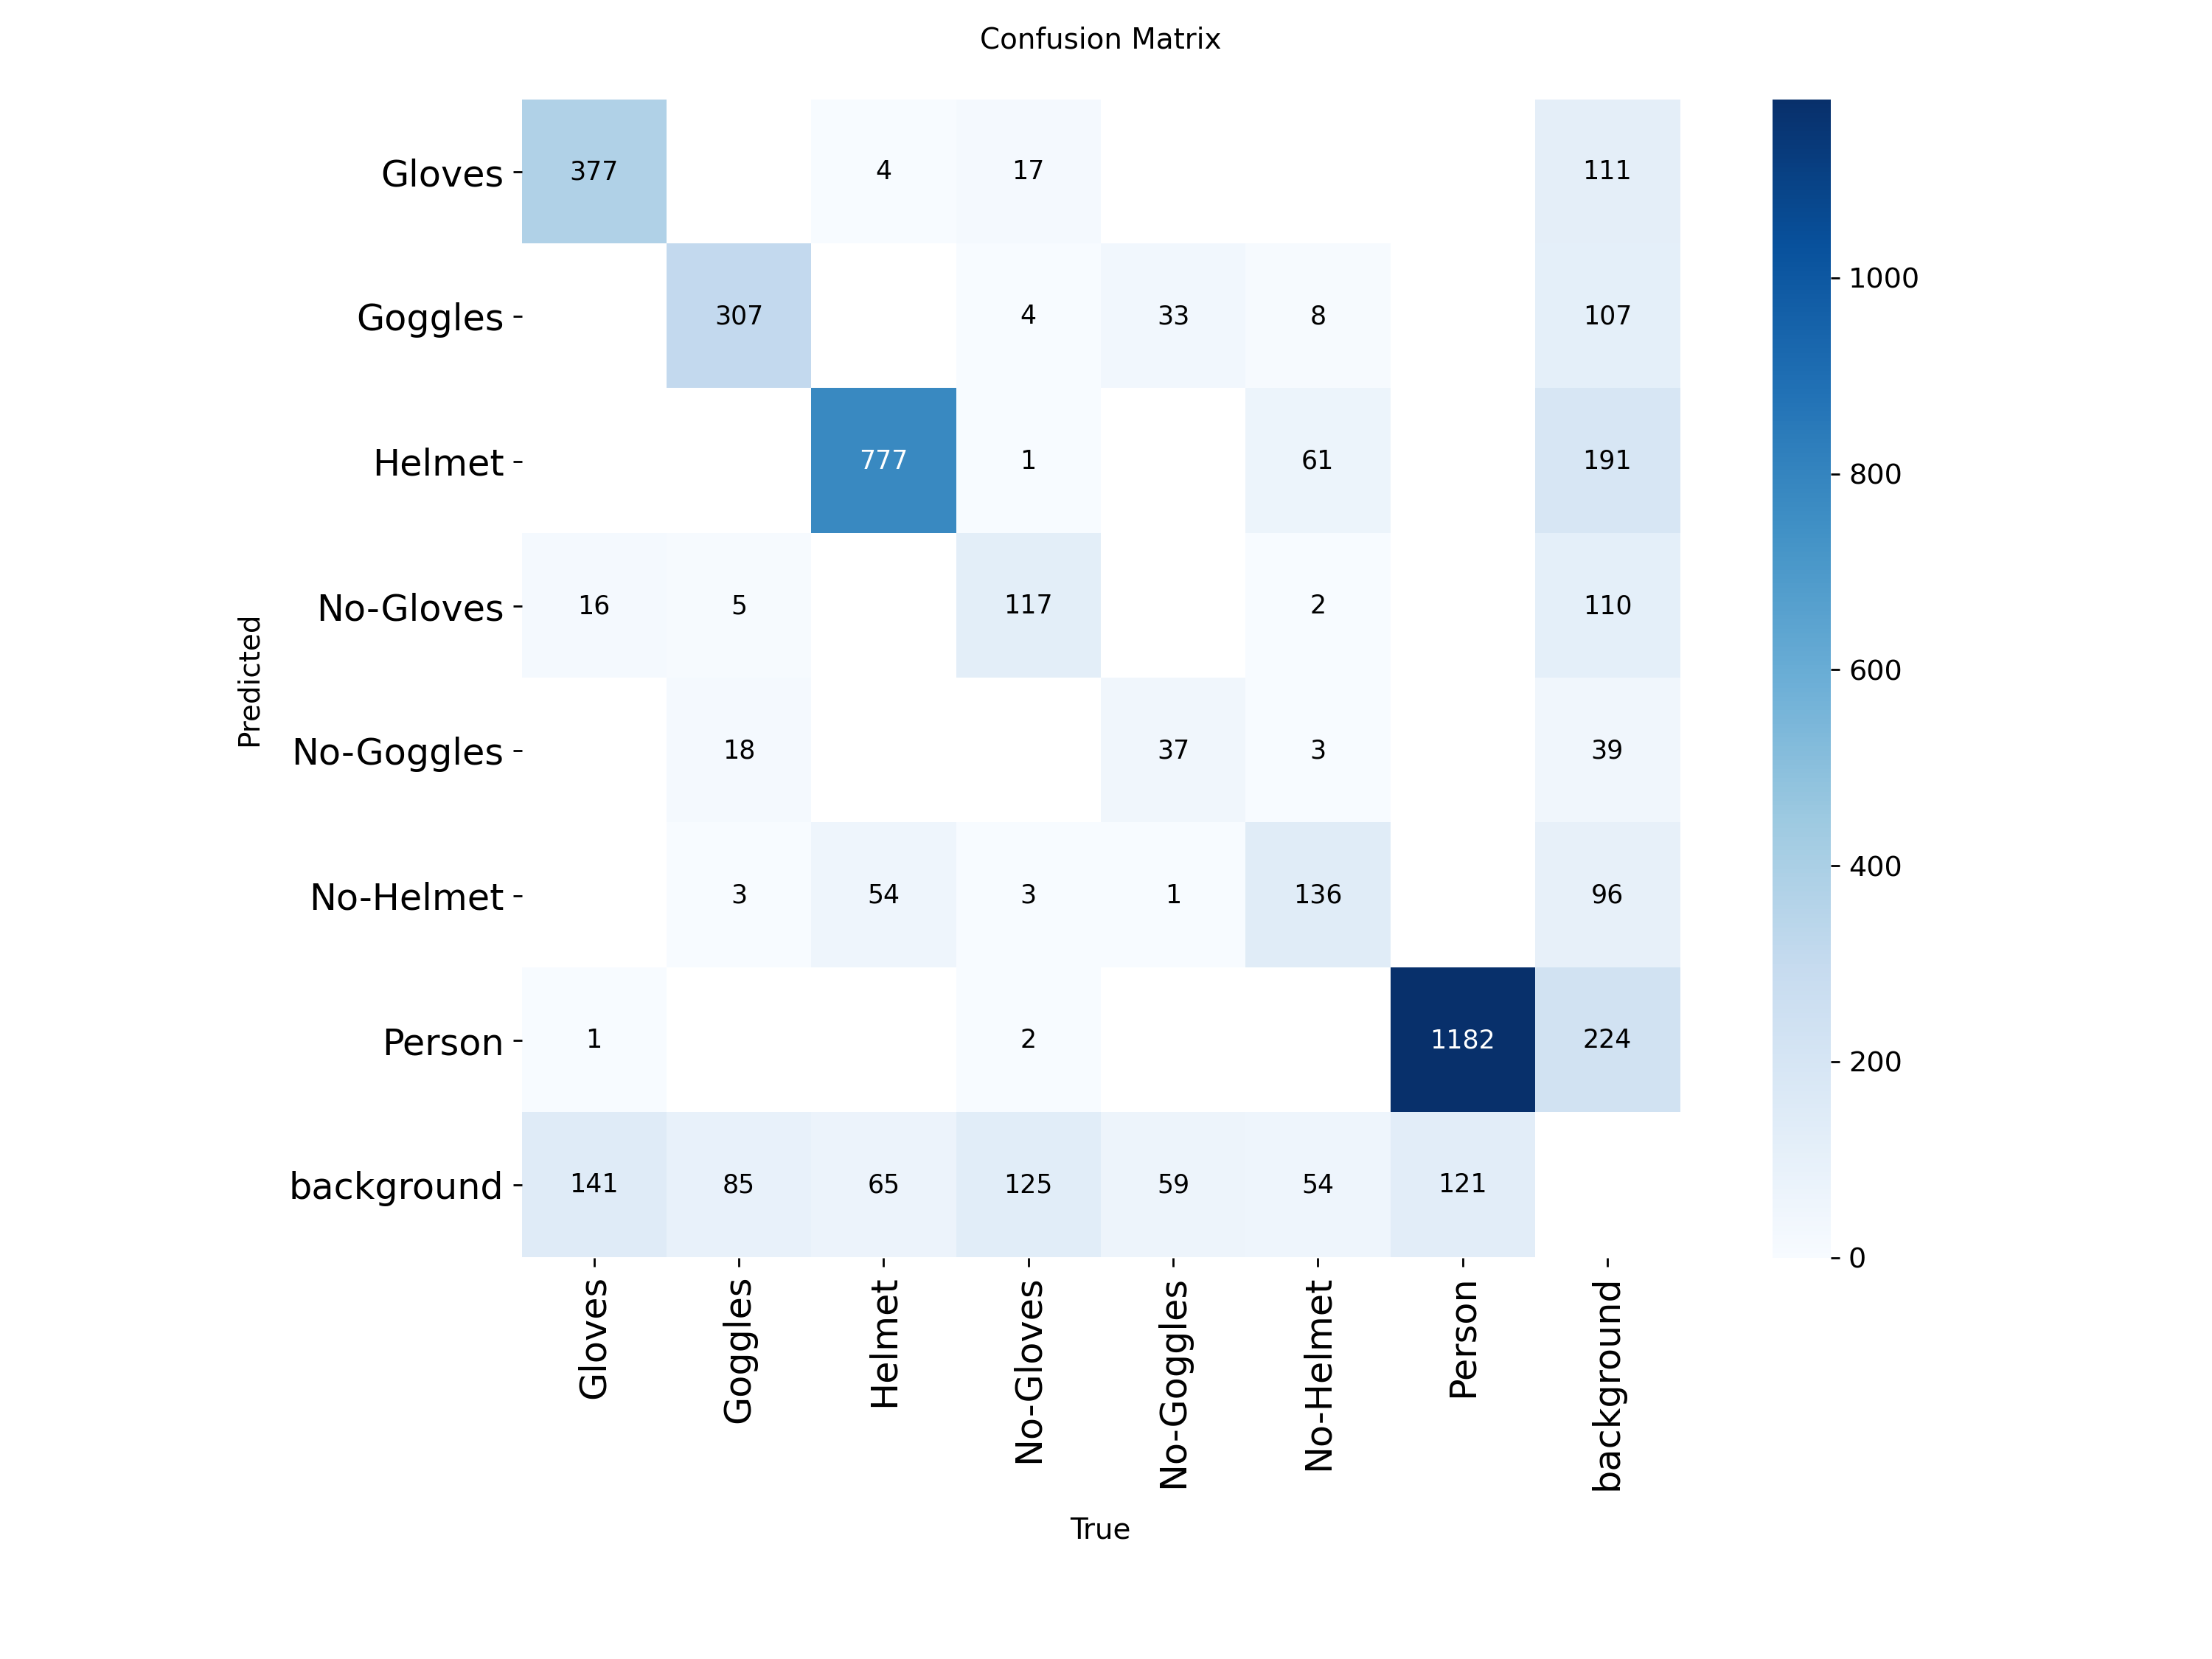

Displaying: confusion_matrix_normalized.png


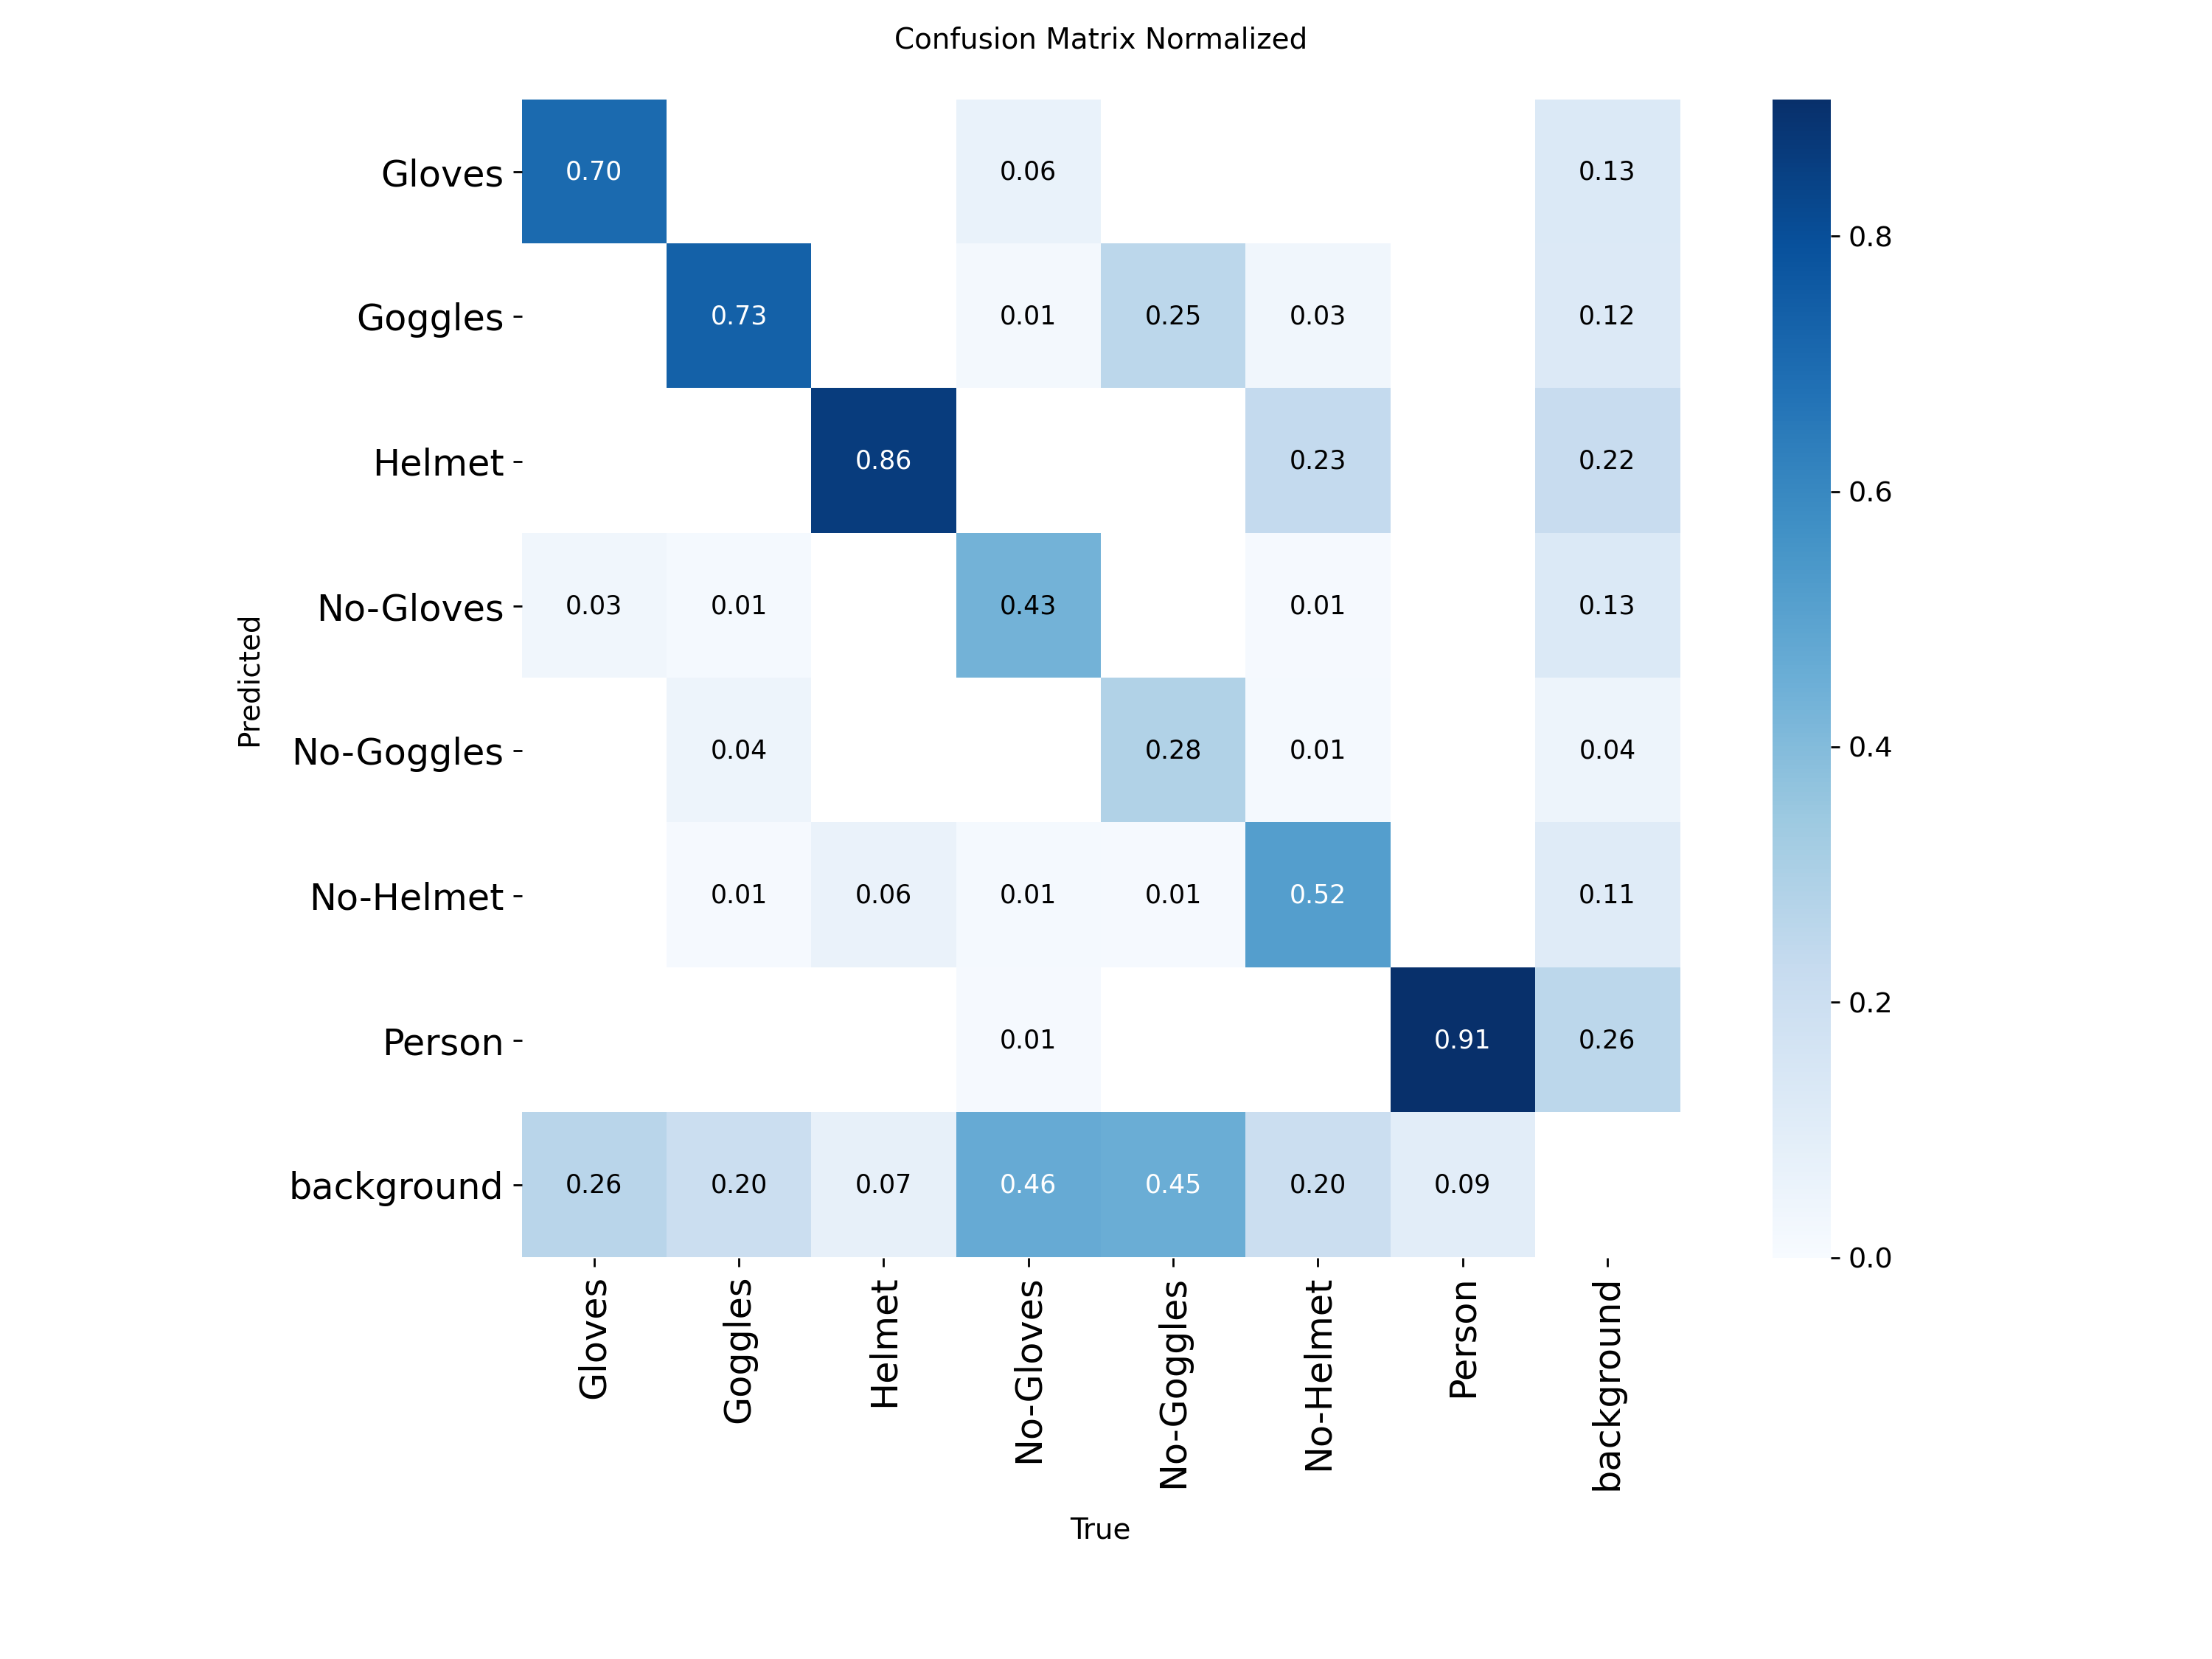

Missing: PR_curve.png
Missing: P_curve.png
Missing: R_curve.png
Missing: F1_curve.png


In [ ]:

figure_candidates = [
    RUN_DIR / "results.png",
    RUN_DIR / "confusion_matrix.png",
    RUN_DIR / "confusion_matrix_normalized.png",
    RUN_DIR / "PR_curve.png",
    RUN_DIR / "P_curve.png",
    RUN_DIR / "R_curve.png",
    RUN_DIR / "F1_curve.png",
]

for fig_path in figure_candidates:
    if fig_path.exists():
        print("Displaying:", fig_path.name)
        display(IPyImage(filename=str(fig_path)))
    else:
        print("Missing:", fig_path.name)


In [ ]:
results_csv = RUN_DIR / "results.csv"

assert results_csv.exists(), f"results.csv not found: {results_csv}"

df_results = pd.read_csv(results_csv)
display(df_results.tail())

# Save final epoch row for report comparison
final_row = df_results.tail(1).copy()
final_row.to_csv(RUN_DIR / "final_epoch_metrics_yolo26.csv", index=False)
print("Saved final metrics:", RUN_DIR / "final_epoch_metrics_yolo26.csv")


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,19587.1,0.89519,0.56805,0.00966,0.65191,0.62387,0.63812,0.49343,0.79763,0.92486,0.00913,0.000099,0.000099,0.000099
46,47,20088.1,0.88460,0.55520,0.00953,0.65046,0.62723,0.63846,0.49097,0.79192,0.93831,0.00897,0.000081,0.000081,0.000081
47,48,20572.5,0.88063,0.55294,0.00942,0.62716,0.63304,0.63616,0.49041,0.79224,0.93600,0.00900,0.000063,0.000063,0.000063
48,49,21039.9,0.87813,0.54754,0.00936,0.62975,0.63228,0.63740,0.49119,0.79797,0.93601,0.00912,0.000045,0.000045,0.000045
49,50,21519.5,0.87153,0.53546,0.00929,0.62754,0.63466,0.63826,0.49315,0.79210,0.93525,0.00902,0.000027,0.000027,0.000027


Saved final metrics: D:\Training + AI\PPE Train\runs_yolo26\yolo26n_ppe\final_epoch_metrics_yolo26.csv


In [ ]:
TEST_IMAGES = DATASET_DIR / "test" / "images"
assert TEST_IMAGES.exists(), f"Test image folder not found: {TEST_IMAGES}"

predict_results = best_model.predict(
    source=str(TEST_IMAGES),
    imgsz=IMGSZ,
    conf=0.25,
    iou=0.7,
    device=DEVICE,
    save=True,
    project=str(RUN_PROJECT),
    name="yolo26n_ppe_test_predictions",
    exist_ok=True,
)

PRED_DIR = RUN_PROJECT / "yolo26n_ppe_test_predictions"
print("Prediction output directory:", PRED_DIR)



image 1/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00014_jpg.rf.fa33a09a66f6eb8df994874ccc7827bc.jpg: 640x640 1 Helmet, 1 No-Gloves, 1 No-Helmet, 2 Persons, 21.2ms
image 2/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00020_jpg.rf.f89a79028615b714d2201f601f91b0e6.jpg: 640x640 1 No-Gloves, 4 Persons, 21.3ms
image 3/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00022_jpg.rf.80ae870a90f464ef0e792eb84c80bc55.jpg: 640x640 1 No-Gloves, 1 Person, 24.2ms
image 4/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\000240_jpeg.rf.8fa0b890a19233c10359582e7dd3ab8a.jpg: 640x640 1 Goggles, 1 Helmet, 1 Person, 20.8ms
image 5/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00085_jpg.rf.b59504fd39c522797b95da7c47f29ea5.jpg: 640x640 1 No-Gloves, 2 No-Goggless, 2 No-Helmets, 1 Person, 21.6ms
image 6/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\000915_jpeg.rf.3d29780328f72dd9d6432eccadafd5a2.jpg: 640x640 1 Goggles, 1 Helmet, 1 Person, 24

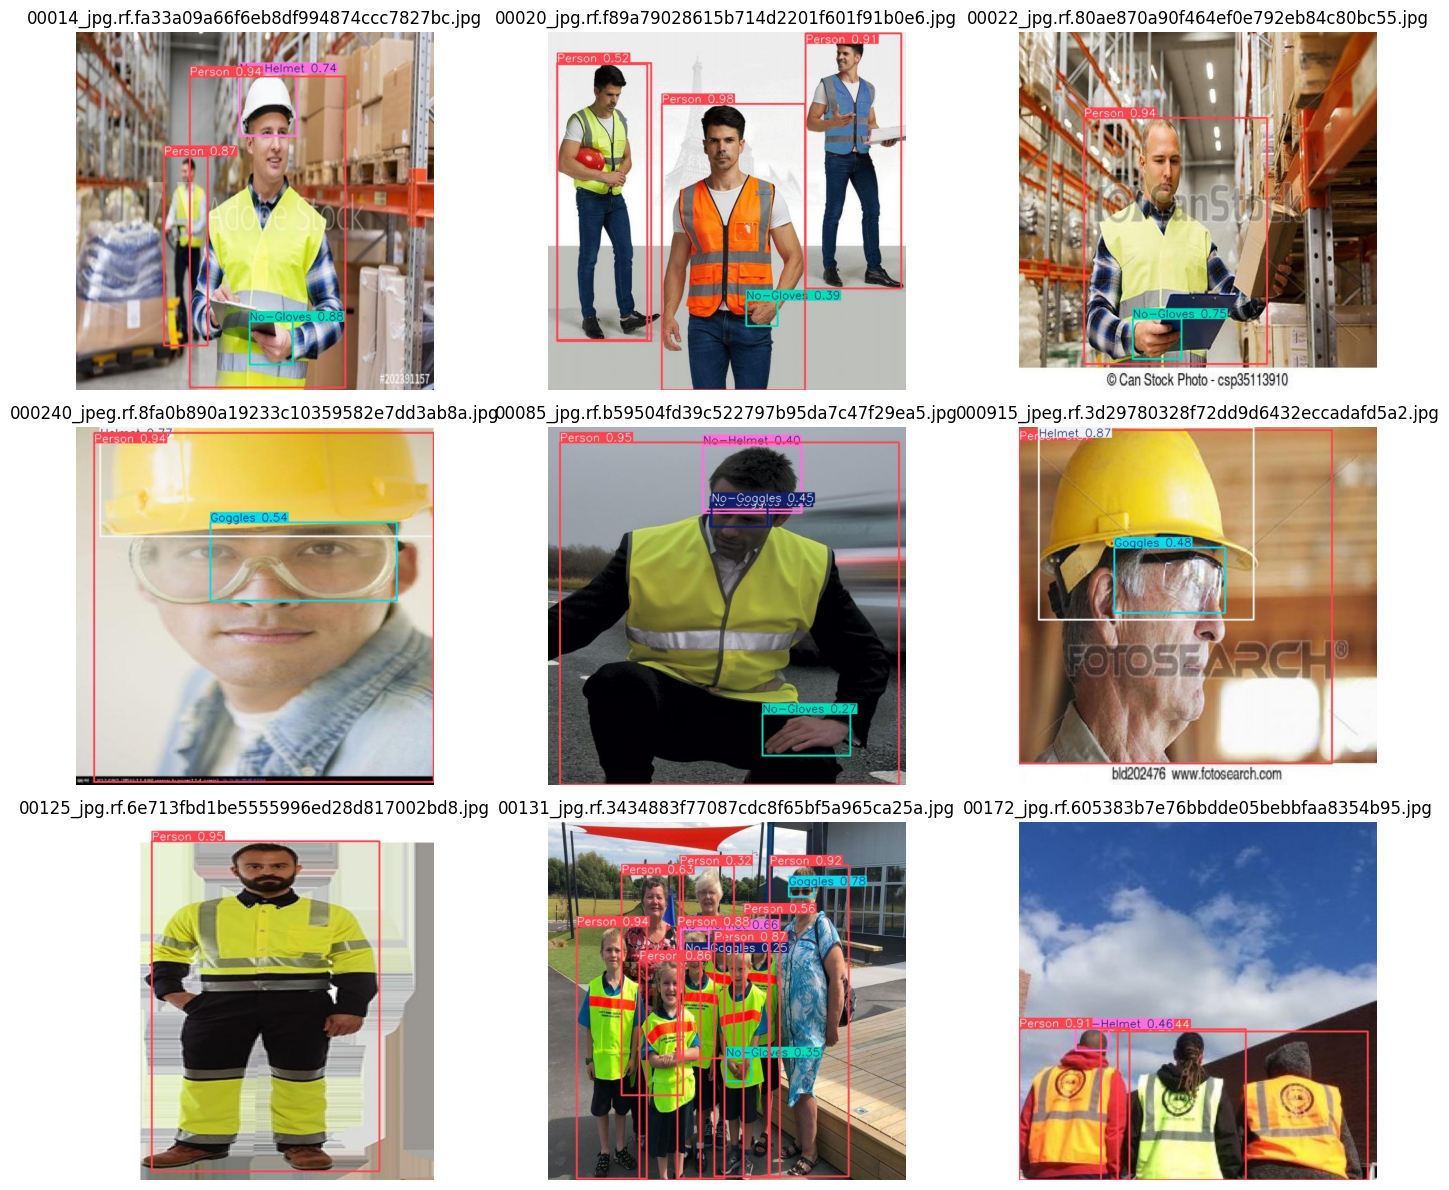

In [ ]:
def display_image_grid(image_paths, max_images=9, cols=3):
    image_paths = list(image_paths)[:max_images]
    if not image_paths:
        print("No prediction images found.")
        return

    rows = (len(image_paths) + cols - 1) // cols
    plt.figure(figsize=(cols * 5, rows * 4))

    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

pred_images = sorted([p for p in PRED_DIR.glob("*.*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
display_image_grid(pred_images, max_images=9, cols=3)


In [ ]:

print("Use these files:")
print("best.pt for web/demo:", BEST_PT)
print("last.pt for resume training:", LAST_PT)

SUBMISSION_DIR = PROJECT_ROOT / "submission_artifacts" / "yolo26"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

if BEST_PT.exists():
    shutil.copy2(BEST_PT, SUBMISSION_DIR / "best.pt")
if LAST_PT.exists():
    shutil.copy2(LAST_PT, SUBMISSION_DIR / "last.pt")
if results_csv.exists():
    shutil.copy2(results_csv, SUBMISSION_DIR / "results.csv")

print("Copied artifacts to:", SUBMISSION_DIR)


Use these files:
best.pt for web/demo: D:\Training + AI\PPE Train\runs_yolo26\yolo26n_ppe\weights\best.pt
last.pt for resume training: D:\Training + AI\PPE Train\runs_yolo26\yolo26n_ppe\weights\last.pt
Copied artifacts to: D:\Training + AI\PPE Train\submission_artifacts\yolo26


## Submission checklist

Before uploading to MS Teams, make sure the following are included:

1. LaTeX report source + compiled PDF.
2. This `.ipynb` notebook with all outputs visible.
3. YOLO26 weights:
   - `best.pt`
   - `last.pt`
4. Result files:
   - `results.csv`
   - `confusion_matrix.png`
   - `results.png`
   - sample prediction images
5. Presentation slides: `.pptx` or `.pdf`.

Important: the numbers in the report must match the notebook outputs.
